# Tuned RF-XGBoost Shock-aware Ensemble for CPI MoM Inflation

Notebook clean code để tinh chỉnh mô hình ensemble giữa **Random Forest** và **XGBoost** cho bài toán dự báo `cpi_mom_inflation`.

Mục tiêu:

- Giữ cấu trúc tốt nhất từ các thử nghiệm trước: RF/XGBoost + shock-aware features.
- Tuning Random Forest bằng TimeSeriesSplit.
- Tuning XGBoost với `shock_weight` để học tốt hơn các điểm shock.
- Tuning trọng số ensemble giữa RF và Shock-weighted XGBoost trên validation set.
- Đánh giá tổng thể, đánh giá riêng shock vs non-shock.
- Vẽ forecast, đánh dấu statistical shock và event windows.
- Xuất bảng kết quả và prediction details phục vụ luận văn.

Lưu ý: notebook không ép R² đạt một mức cụ thể. Mô hình tốt nhất được chọn theo RMSE trên validation và đánh giá cuối trên test set.

In [1]:
import os, warnings, random
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import jarque_bera
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf

from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.model_selection import TimeSeriesSplit, ParameterGrid
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except Exception:
    HAS_XGB = False
    print("xgboost is not installed. Please install xgboost to run this notebook.")

try:
    import shap
    HAS_SHAP = True
except Exception:
    HAS_SHAP = False
    print("shap is not installed. SHAP feature selection will be skipped.")

plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

if not hasattr(np, "matrix"):
    np.matrix = np.ndarray

DATA_DIR = os.path.join(os.getcwd(), "data", "processed")
OUTPUT_DIR = os.path.join(os.getcwd(), "outputs", "step8_tuned_rf_xgb_shock_ensemble")
os.makedirs(OUTPUT_DIR, exist_ok=True)

MODEL_TAG = "tuned_rf_xgb_shock_ensemble"

print("Data:", DATA_DIR)
print("Output:", OUTPUT_DIR)

Data: d:\Nam4-HK1\KLTN\Vietnam_economic_lakehouse\model_test\data\processed
Output: d:\Nam4-HK1\KLTN\Vietnam_economic_lakehouse\model_test\outputs\step8_tuned_rf_xgb_shock_ensemble


In [2]:
# Load CPI and macro-financial data
DATA_FILE = os.path.join(DATA_DIR, "cpi_forecast_selected_variables.csv")
raw = pd.read_csv(DATA_FILE)

if "date" in raw.columns:
    raw["date"] = pd.to_datetime(raw["date"])
    df_raw = raw.sort_values("date").set_index("date")
else:
    df_raw = pd.read_csv(DATA_FILE, index_col=0, parse_dates=True).sort_index()

target_var = "cpi_mom_inflation"
exog_vars = [c for c in df_raw.columns if c != target_var]

df_raw = df_raw[[target_var] + exog_vars].copy().dropna()

print("Raw shape:", df_raw.shape)
print("Raw period:", df_raw.index.min().date(), "to", df_raw.index.max().date())
print("Missing:", df_raw.isnull().sum().sum())
print("Target:", target_var)
print("Exogenous variables:", exog_vars)

Raw shape: (360, 9)
Raw period: 1995-01-01 to 2024-12-01
Missing: 0
Target: cpi_mom_inflation
Exogenous variables: ['broad_money', 'ppi_qoq', 'wti', 'gold', 'policy_rate', 'VNINDEX', 'NIKKEI225', 'USDVND']


In [3]:
# Stationarity-safe transformation for exogenous variables.
# Target CPI MoM inflation is kept in level form.

def safe_stationarity_classification(series):
    s = pd.Series(series).dropna()
    s = pd.to_numeric(s, errors="coerce").dropna()

    if len(s) < 30 or s.nunique() <= 1:
        return "I(0)", np.nan, np.nan

    try:
        adf_p = adfuller(s, autolag="AIC", regression="c")[1]
    except Exception:
        adf_p = 1.0

    try:
        kpss_p = kpss(s, regression="c", nlags="auto")[1]
    except Exception:
        kpss_p = 0.01

    status = "I(0)" if (adf_p < 0.05 and kpss_p > 0.05) else "I(1)"
    return status, adf_p, kpss_p

transformed = {target_var: df_raw[target_var]}
stationarity_report = []

for col in exog_vars:
    status, adf_p, kpss_p = safe_stationarity_classification(df_raw[col])

    if status == "I(0)":
        new_col = col
        transformed[new_col] = df_raw[col]
        method = "level"
    else:
        if (df_raw[col] > 0).all():
            new_col = f"dlog_{col}"
            transformed[new_col] = np.log(df_raw[col]).diff()
            method = "log_diff"
        else:
            new_col = f"diff_{col}"
            transformed[new_col] = df_raw[col].diff()
            method = "diff"

    stationarity_report.append({
        "variable": col,
        "status": status,
        "adf_p": adf_p,
        "kpss_p": kpss_p,
        "method": method,
        "new_col": new_col
    })

df = pd.DataFrame(transformed, index=df_raw.index).dropna()
exog_transformed = [c for c in df.columns if c != target_var]
stationarity_df = pd.DataFrame(stationarity_report)

print("Transformed data shape:", df.shape)
print(stationarity_df)

Transformed data shape: (359, 9)
      variable status     adf_p  kpss_p    method           new_col
0  broad_money   I(1)  0.280602    0.01  log_diff  dlog_broad_money
1      ppi_qoq   I(1)  0.307828    0.01      diff      diff_ppi_qoq
2          wti   I(1)  0.121689    0.01  log_diff          dlog_wti
3         gold   I(1)  0.989363    0.01  log_diff         dlog_gold
4  policy_rate   I(1)  0.121117    0.01  log_diff  dlog_policy_rate
5      VNINDEX   I(1)  0.721155    0.01  log_diff      dlog_VNINDEX
6    NIKKEI225   I(1)  0.991552    0.01  log_diff    dlog_NIKKEI225
7       USDVND   I(1)  0.786262    0.01  log_diff       dlog_USDVND


C:\Users\HP\AppData\Local\Temp\ipykernel_26656\3626026806.py:17: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_p = kpss(s, regression="c", nlags="auto")[1]
C:\Users\HP\AppData\Local\Temp\ipykernel_26656\3626026806.py:17: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_p = kpss(s, regression="c", nlags="auto")[1]
C:\Users\HP\AppData\Local\Temp\ipykernel_26656\3626026806.py:17: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_p = kpss(s, regression="c", nlags="auto")[1]
C:\Users\HP\AppData\Local\Temp\ipykernel_26656\3626026806.py:17: InterpolationWarning: The test statistic is outside of the range of p-values availa

In [4]:
# Economic event features and statistical shock labels

def add_event_features(index):
    event = pd.DataFrame(index=index)
    event["gfc_2008_2011"] = ((index >= "2008-01-01") & (index <= "2011-12-01")).astype(float)
    event["covid_period"] = ((index >= "2020-03-01") & (index <= "2021-12-01")).astype(float)
    event["reopening_commodity_2022"] = ((index >= "2022-01-01") & (index <= "2022-12-01")).astype(float)
    event["ukraine_war_commodity"] = ((index >= "2022-02-01") & (index <= "2023-12-01")).astype(float)
    event["tet_window"] = pd.Index(index.month).isin([1, 2]).astype(float)
    event["school_fee_window"] = pd.Index(index.month).isin([8, 9, 10]).astype(float)
    event["year_end_window"] = pd.Index(index.month).isin([11, 12]).astype(float)
    return event


def add_statistical_shock_labels(data, target_col, z_threshold=1.5):
    out = data.copy()
    y = out[target_col]
    roll_mean = y.rolling(12).mean().shift(1)
    roll_std = y.rolling(12).std().shift(1)
    out["inflation_zscore_12"] = (y - roll_mean) / roll_std
    out["stat_shock"] = (out["inflation_zscore_12"].abs() > z_threshold).astype(float)
    out["positive_stat_shock"] = (out["inflation_zscore_12"] > z_threshold).astype(float)
    out["negative_stat_shock"] = (out["inflation_zscore_12"] < -z_threshold).astype(float)
    return out

SHOCK_Z_THRESHOLD = 1.5
df_labeled = add_statistical_shock_labels(df, target_var, z_threshold=SHOCK_Z_THRESHOLD)
event_df = add_event_features(df_labeled.index)
df_labeled = pd.concat([df_labeled, event_df], axis=1)

event_cols = event_df.columns.tolist()

print("Shock labels created")
print("Total statistical shocks:", int(df_labeled["stat_shock"].sum()))
print("Event columns:", event_cols)

Shock labels created
Total statistical shocks: 55
Event columns: ['gfc_2008_2011', 'covid_period', 'reopening_commodity_2022', 'ukraine_war_commodity', 'tet_window', 'school_fee_window', 'year_end_window']


In [5]:
# Feature engineering

def create_features(data, target_col, exog_cols, max_target_lag=24, use_current_exog=True):
    X = pd.DataFrame(index=data.index)
    y = data[target_col].copy()

    if use_current_exog:
        for col in exog_cols:
            X[col] = data[col]

    # Target lags
    for lag in range(1, max_target_lag + 1):
        X[f"{target_col}_lag{lag}"] = y.shift(lag)

    # Exogenous lag, rolling, and shock indicators
    for col in exog_cols:
        for lag in [1, 2, 3, 6, 12]:
            X[f"{col}_lag{lag}"] = data[col].shift(lag)
        for window in [3, 6, 12]:
            X[f"{col}_roll_mean_{window}"] = data[col].rolling(window).mean().shift(1)
            X[f"{col}_roll_std_{window}"] = data[col].rolling(window).std().shift(1)

        abs_lag1 = data[col].shift(1).abs()
        threshold = abs_lag1.rolling(24, min_periods=12).quantile(0.85)
        X[f"{col}_abs_lag1"] = abs_lag1
        X[f"{col}_shock_lag1"] = (abs_lag1 > threshold).astype(float)

    # Target rolling statistics
    for window in [3, 6, 12]:
        X[f"{target_col}_roll_mean_{window}"] = y.rolling(window).mean().shift(1)
        X[f"{target_col}_roll_std_{window}"] = y.rolling(window).std().shift(1)
        X[f"{target_col}_roll_min_{window}"] = y.rolling(window).min().shift(1)
        X[f"{target_col}_roll_max_{window}"] = y.rolling(window).max().shift(1)

    # Past-only shock score features
    roll_mean_12 = y.rolling(12).mean().shift(1)
    roll_std_12 = y.rolling(12).std().shift(1)
    X[f"{target_col}_past_zscore_12"] = (y.shift(1) - roll_mean_12) / roll_std_12
    X["past_positive_inflation_shock"] = (X[f"{target_col}_past_zscore_12"] > 1.5).astype(float)
    X["past_negative_inflation_shock"] = (X[f"{target_col}_past_zscore_12"] < -1.5).astype(float)
    X["past_abs_inflation_shock"] = X[f"{target_col}_past_zscore_12"].abs()

    # Seasonality and event windows
    month = data.index.month
    X["month_sin"] = np.sin(2 * np.pi * month / 12)
    X["month_cos"] = np.cos(2 * np.pi * month / 12)
    X["quarter_sin"] = np.sin(2 * np.pi * data.index.quarter / 4)
    X["quarter_cos"] = np.cos(2 * np.pi * data.index.quarter / 4)
    X["is_jan"] = (month == 1).astype(float)
    X["is_feb"] = (month == 2).astype(float)
    X["is_sep"] = (month == 9).astype(float)
    X["is_dec"] = (month == 12).astype(float)
    X = pd.concat([X, add_event_features(data.index)], axis=1)

    # Regime feature
    X["inflation_volatility_12m"] = y.rolling(12).std().shift(1)
    high_vol_threshold = X["inflation_volatility_12m"].quantile(0.75)
    X["high_vol_regime"] = (X["inflation_volatility_12m"] > high_vol_threshold).astype(float)

    # Interaction features
    key_exog = [c for c in exog_cols if any(k in c.lower() for k in ["wti", "gold", "usdvnd", "money", "policy"])]
    for col in key_exog[:5]:
        if f"{col}_lag1" in X.columns:
            X[f"lag1_x_{col}_lag1"] = X[f"{target_col}_lag1"] * X[f"{col}_lag1"]
            X[f"vol_x_{col}_lag1"] = X["inflation_volatility_12m"] * X[f"{col}_lag1"]

    label_cols = ["stat_shock", "positive_stat_shock", "negative_stat_shock", "inflation_zscore_12"]
    labels = data[label_cols].copy()

    feature_df = pd.concat([X, y.rename(target_col), labels], axis=1).dropna()
    X_final = feature_df.drop(columns=[target_col] + label_cols)
    y_final = feature_df[target_col]
    labels_final = feature_df[label_cols]

    return X_final, y_final, labels_final, high_vol_threshold

USE_CURRENT_EXOG = True
X, y, labels, high_vol_threshold = create_features(
    df_labeled,
    target_var,
    exog_transformed,
    max_target_lag=24,
    use_current_exog=USE_CURRENT_EXOG
)

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("Labels shape:", labels.shape)
print("Feature period:", X.index.min().date(), "to", X.index.max().date())
print("Shock count:", int(labels["stat_shock"].sum()))

Feature matrix shape: (335, 179)
Target shape: (335,)
Labels shape: (335, 4)
Feature period: 1997-02-01 to 2024-12-01
Shock count: 55


In [6]:
# Chronological split: 80/10/10
n_total = len(X)
train_end = int(0.80 * n_total)
val_end = int(0.90 * n_total)

X_train, y_train, labels_train = X.iloc[:train_end], y.iloc[:train_end], labels.iloc[:train_end]
X_val, y_val, labels_val = X.iloc[train_end:val_end], y.iloc[train_end:val_end], labels.iloc[train_end:val_end]
X_test, y_test, labels_test = X.iloc[val_end:], y.iloc[val_end:], labels.iloc[val_end:]

X_train_full = pd.concat([X_train, X_val])
y_train_full = pd.concat([y_train, y_val])
labels_train_full = pd.concat([labels_train, labels_val])

print("Split")
print(f"Train: {X_train.shape}, {X_train.index.min().date()} to {X_train.index.max().date()}, shocks={int(labels_train['stat_shock'].sum())}")
print(f"Val:   {X_val.shape}, {X_val.index.min().date()} to {X_val.index.max().date()}, shocks={int(labels_val['stat_shock'].sum())}")
print(f"Test:  {X_test.shape}, {X_test.index.min().date()} to {X_test.index.max().date()}, shocks={int(labels_test['stat_shock'].sum())}")

Split
Train: (268, 179), 1997-02-01 to 2019-05-01, shocks=45
Val:   (33, 179), 2019-06-01 to 2022-02-01, shocks=6
Test:  (34, 179), 2022-03-01 to 2024-12-01, shocks=4


Running SHAP selection...
Selected top 40 features
                       feature  importance
                     month_sin    0.255359
                      dlog_wti    0.054558
         dlog_broad_money_lag3    0.052994
       cpi_mom_inflation_lag24    0.050525
 cpi_mom_inflation_roll_mean_3    0.045958
       cpi_mom_inflation_lag12    0.043375
 cpi_mom_inflation_roll_mean_6    0.035551
          dlog_USDVND_abs_lag1    0.034645
                    tet_window    0.031968
 cpi_mom_inflation_roll_std_12    0.028767
        dlog_broad_money_lag12    0.027681
          dlog_gold_roll_std_6    0.027427
                     dlog_gold    0.026133
       dlog_VNINDEX_roll_std_3    0.019787
       lag1_x_dlog_USDVND_lag1    0.019400
cpi_mom_inflation_roll_mean_12    0.017212
        cpi_mom_inflation_lag6    0.016603
        cpi_mom_inflation_lag2    0.015153
      dlog_USDVND_roll_mean_12    0.013226
       cpi_mom_inflation_lag19    0.012719
                  dlog_VNINDEX    0.012648
   

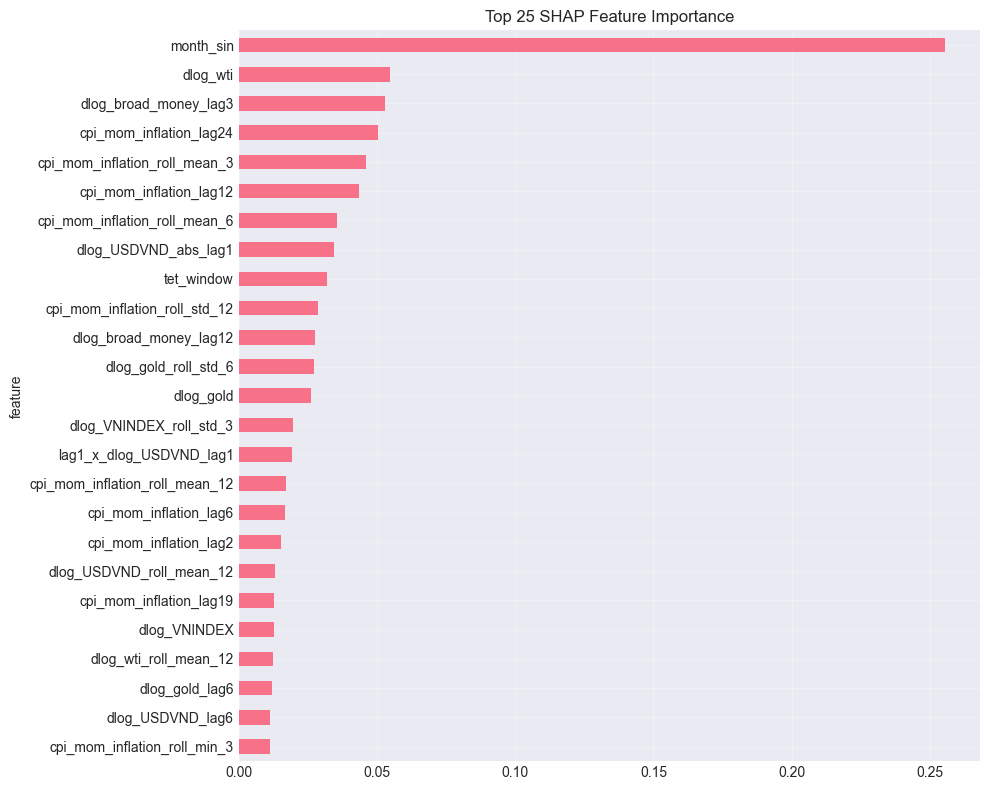

Selected feature count: 40


In [7]:
# SHAP feature selection from training set only.
USE_SHAP_SELECTION = HAS_SHAP and HAS_XGB
TOP_N = 40

if USE_SHAP_SELECTION:
    print("Running SHAP selection...")
    xgb_for_shap = XGBRegressor(
        n_estimators=150,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="reg:squarederror",
        random_state=SEED,
        n_jobs=-1,
        verbosity=0
    )
    shap_weights = 1.0 + 2.0 * labels_train["stat_shock"].values
    xgb_for_shap.fit(X_train, y_train, sample_weight=shap_weights, verbose=False)

    explainer = shap.TreeExplainer(xgb_for_shap)
    shap_values = explainer.shap_values(X_val)
    shap_importance = np.abs(shap_values).mean(axis=0)
    shap_df = pd.DataFrame({"feature": X_train.columns, "importance": shap_importance}).sort_values("importance", ascending=False)
    selected_features = shap_df.head(TOP_N)["feature"].tolist()

    print(f"Selected top {TOP_N} features")
    print(shap_df.head(TOP_N).to_string(index=False))

    fig, ax = plt.subplots(figsize=(10, 8))
    shap_df.head(25).iloc[::-1].plot(x="feature", y="importance", kind="barh", ax=ax, legend=False)
    ax.set_title("Top 25 SHAP Feature Importance")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "ensemble_shap_feature_importance.png"), dpi=150)
    plt.show()
else:
    selected_features = X_train.columns.tolist()
    print("SHAP skipped. Using all features:", len(selected_features))

X_train_sel = X_train[selected_features]
X_val_sel = X_val[selected_features]
X_test_sel = X_test[selected_features]
X_train_full_sel = X_train_full[selected_features]

print("Selected feature count:", len(selected_features))

In [8]:
# Sample weight builder for shock-aware XGBoost

def build_sample_weights(labels, base_weight=1.0, shock_weight=3.0, positive_extra=0.5, negative_extra=0.5):
    w = pd.Series(base_weight, index=labels.index, dtype=float)
    w += shock_weight * labels["stat_shock"].astype(float)
    w += positive_extra * labels["positive_stat_shock"].astype(float)
    w += negative_extra * labels["negative_stat_shock"].astype(float)
    return w

print("Preview shock weights")
preview_weights = build_sample_weights(labels_train, shock_weight=3.0)
print(preview_weights.describe())
print("Mean non-shock weight:", preview_weights[labels_train["stat_shock"] == 0].mean())
print("Mean shock weight:", preview_weights[labels_train["stat_shock"] == 1].mean())

Preview shock weights
count    268.000000
mean       1.587687
std        1.310701
min        1.000000
25%        1.000000
50%        1.000000
75%        1.000000
max        4.500000
dtype: float64
Mean non-shock weight: 1.0
Mean shock weight: 4.5


In [9]:
# Tune Random Forest with TimeSeriesSplit

def tune_random_forest(X_train, y_train):
    param_grid = list(ParameterGrid({
        "n_estimators": [200, 400],
        "max_depth": [6, 8, 10, None],
        "min_samples_leaf": [1, 2, 4, 8],
        "max_features": ["sqrt", 0.5, 0.8]
    }))

    tss = TimeSeriesSplit(n_splits=4)
    best_score = np.inf
    best_params = None
    rows = []

    for params in param_grid:
        fold_scores = []
        for tr_idx, va_idx in tss.split(X_train):
            X_tr, X_va = X_train.iloc[tr_idx], X_train.iloc[va_idx]
            y_tr, y_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]
            model = RandomForestRegressor(**params, random_state=SEED, n_jobs=-1)
            model.fit(X_tr, y_tr)
            pred = model.predict(X_va)
            fold_scores.append(np.sqrt(mean_squared_error(y_va, pred)))

        score = np.mean(fold_scores)
        rows.append({**params, "cv_rmse": score})
        if score < best_score:
            best_score = score
            best_params = params

    return best_params, best_score, pd.DataFrame(rows).sort_values("cv_rmse")

print("Tuning Random Forest...")
best_rf_params, best_rf_cv, rf_cv_df = tune_random_forest(X_train_sel, y_train)
print("Best RF params:", best_rf_params)
print("Best RF CV RMSE:", round(best_rf_cv, 6))
print(rf_cv_df.head(10).to_string(index=False))
rf_cv_df.to_csv(os.path.join(OUTPUT_DIR, "rf_cv_results.csv"), index=False)

Tuning Random Forest...
Best RF params: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 200}
Best RF CV RMSE: 0.540883
 max_depth max_features  min_samples_leaf  n_estimators  cv_rmse
      10.0         sqrt                 1           200 0.540883
      10.0         sqrt                 1           400 0.542456
      10.0         sqrt                 2           200 0.543662
      10.0         sqrt                 2           400 0.544562
       8.0         sqrt                 2           200 0.544770
       NaN         sqrt                 2           400 0.544850
       NaN         sqrt                 1           200 0.545292
       NaN         sqrt                 2           200 0.545316
       NaN         sqrt                 1           400 0.545809
       8.0         sqrt                 1           400 0.546165


In [10]:
# Tune XGBoost with shock_weight as hyperparameter

def tune_xgb_with_weights(X_train, y_train, labels_train):
    if not HAS_XGB:
        raise RuntimeError("xgboost is required.")

    param_grid = list(ParameterGrid({
        "n_estimators": [100, 200, 400],
        "max_depth": [2, 3, 4, 5],
        "learning_rate": [0.01, 0.03, 0.05, 0.08],
        "subsample": [0.75, 0.9, 1.0],
        "colsample_bytree": [0.75, 0.9, 1.0],
        "reg_alpha": [0.0, 0.1, 0.5],
        "reg_lambda": [0.5, 1.0, 2.0],
        "shock_weight": [0.0, 1.0, 2.0, 3.0, 5.0]
    }))

    rng = np.random.default_rng(SEED)
    if len(param_grid) > 180:
        param_grid = list(rng.choice(param_grid, size=180, replace=False))

    tss = TimeSeriesSplit(n_splits=4)
    best_score = np.inf
    best_params = None
    rows = []

    for params_all in param_grid:
        params = params_all.copy()
        shock_weight = params.pop("shock_weight")
        fold_rmse = []
        fold_shock_rmse = []

        for tr_idx, va_idx in tss.split(X_train):
            X_tr, X_va = X_train.iloc[tr_idx], X_train.iloc[va_idx]
            y_tr, y_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]
            lab_tr, lab_va = labels_train.iloc[tr_idx], labels_train.iloc[va_idx]
            sample_weight = build_sample_weights(lab_tr, shock_weight=shock_weight)

            model = XGBRegressor(
                **params,
                objective="reg:squarederror",
                random_state=SEED,
                n_jobs=-1,
                verbosity=0
            )
            model.fit(X_tr, y_tr, sample_weight=sample_weight, verbose=False)
            pred = model.predict(X_va)
            fold_rmse.append(np.sqrt(mean_squared_error(y_va, pred)))

            shock_mask = lab_va["stat_shock"].astype(bool).values
            if shock_mask.sum() > 0:
                fold_shock_rmse.append(np.sqrt(mean_squared_error(y_va.values[shock_mask], pred[shock_mask])))

        mean_rmse = np.mean(fold_rmse)
        mean_shock_rmse = np.mean(fold_shock_rmse) if len(fold_shock_rmse) > 0 else np.nan
        score = mean_rmse if np.isnan(mean_shock_rmse) else 0.85 * mean_rmse + 0.15 * mean_shock_rmse

        rows.append({**params_all, "cv_rmse": mean_rmse, "cv_shock_rmse": mean_shock_rmse, "score": score})
        if score < best_score:
            best_score = score
            best_params = params_all.copy()

    return best_params, best_score, pd.DataFrame(rows).sort_values("score")

print("Tuning shock-aware XGBoost...")
best_xgb_params_all, best_xgb_score, xgb_cv_df = tune_xgb_with_weights(X_train_sel, y_train, labels_train)
print("Best XGB params including shock_weight:")
print(best_xgb_params_all)
print("Best combined CV score:", round(best_xgb_score, 6))
print(xgb_cv_df.head(10).to_string(index=False))
xgb_cv_df.to_csv(os.path.join(OUTPUT_DIR, "xgb_shock_weighted_cv_results.csv"), index=False)

Tuning shock-aware XGBoost...
Best XGB params including shock_weight:
{'colsample_bytree': 0.75, 'learning_rate': 0.03, 'max_depth': 5, 'n_estimators': 400, 'reg_alpha': 0.1, 'reg_lambda': 2.0, 'shock_weight': 3.0, 'subsample': 0.75}
Best combined CV score: 0.588452
 colsample_bytree  learning_rate  max_depth  n_estimators  reg_alpha  reg_lambda  shock_weight  subsample  cv_rmse  cv_shock_rmse    score
             0.75           0.03          5           400        0.1         2.0           3.0       0.75 0.544543       0.837273 0.588452
             0.75           0.03          4           100        0.0         1.0           2.0       0.75 0.545113       0.845627 0.590190
             0.75           0.05          4           400        0.1         1.0           2.0       0.90 0.550310       0.826931 0.591804
             0.90           0.01          5           200        0.1         1.0           1.0       0.75 0.542071       0.878751 0.592573
             0.75           0.01      

In [11]:
# Train validation models for ensemble weight tuning
best_xgb_params = best_xgb_params_all.copy()
best_shock_weight = best_xgb_params.pop("shock_weight")

# RF trained on train, evaluated on validation
rf_val_model = RandomForestRegressor(**best_rf_params, random_state=SEED, n_jobs=-1)
rf_val_model.fit(X_train_sel, y_train)
rf_val_pred = pd.Series(rf_val_model.predict(X_val_sel), index=y_val.index)

# Shock-weighted XGB trained on train, evaluated on validation
xgb_val_model = XGBRegressor(
    **best_xgb_params,
    objective="reg:squarederror",
    random_state=SEED,
    n_jobs=-1,
    verbosity=0
)
xgb_val_weights = build_sample_weights(labels_train, shock_weight=best_shock_weight)
xgb_val_model.fit(X_train_sel, y_train, sample_weight=xgb_val_weights, verbose=False)
xgb_val_pred = pd.Series(xgb_val_model.predict(X_val_sel), index=y_val.index)

# Tune ensemble weight on validation
weight_grid = np.round(np.linspace(0, 1, 101), 2)
weight_rows = []

for w_rf in weight_grid:
    w_xgb = 1.0 - w_rf
    pred = w_rf * rf_val_pred + w_xgb * xgb_val_pred
    rmse = np.sqrt(mean_squared_error(y_val, pred))
    mae = mean_absolute_error(y_val, pred)
    r2 = r2_score(y_val, pred)

    shock_mask = labels_val["stat_shock"].astype(bool)
    shock_rmse = np.sqrt(mean_squared_error(y_val[shock_mask], pred[shock_mask])) if shock_mask.sum() > 0 else np.nan
    score = rmse if np.isnan(shock_rmse) else 0.90 * rmse + 0.10 * shock_rmse

    weight_rows.append({"w_rf": w_rf, "w_xgb": w_xgb, "val_rmse": rmse, "val_mae": mae, "val_r2": r2, "val_shock_rmse": shock_rmse, "score": score})

weight_df = pd.DataFrame(weight_rows).sort_values("score")
best_w_rf = float(weight_df.iloc[0]["w_rf"])
best_w_xgb = float(weight_df.iloc[0]["w_xgb"])

print("Best ensemble weights on validation")
print(weight_df.head(10).to_string(index=False))
print(f"Best weights -> RF: {best_w_rf:.2f}, XGB: {best_w_xgb:.2f}")

weight_df.to_csv(os.path.join(OUTPUT_DIR, "ensemble_weight_tuning_validation.csv"), index=False)

Best ensemble weights on validation
 w_rf  w_xgb  val_rmse  val_mae   val_r2  val_shock_rmse    score
 1.00   0.00  0.698433 0.511690 0.159085        1.375729 0.766163
 0.99   0.01  0.698568 0.511652 0.158760        1.376325 0.766344
 0.98   0.02  0.698709 0.511613 0.158421        1.376928 0.766531
 0.97   0.03  0.698855 0.511574 0.158070        1.377536 0.766723
 0.96   0.04  0.699006 0.511536 0.157706        1.378151 0.766920
 0.95   0.05  0.699162 0.511497 0.157329        1.378771 0.767123
 0.94   0.06  0.699324 0.511459 0.156939        1.379398 0.767331
 0.93   0.07  0.699491 0.511420 0.156536        1.380030 0.767545
 0.92   0.08  0.699663 0.511381 0.156120        1.380669 0.767764
 0.91   0.09  0.699841 0.511343 0.155692        1.381314 0.767988
Best weights -> RF: 1.00, XGB: 0.00


In [12]:
# Train final RF and Shock-weighted XGB on train + validation, then test
rf_final = RandomForestRegressor(**best_rf_params, random_state=SEED, n_jobs=-1)
rf_final.fit(X_train_full_sel, y_train_full)
rf_test_pred = pd.Series(rf_final.predict(X_test_sel), index=y_test.index, name="rf_pred")

xgb_final = XGBRegressor(
    **best_xgb_params,
    objective="reg:squarederror",
    random_state=SEED,
    n_jobs=-1,
    verbosity=0
)
full_weights = build_sample_weights(labels_train_full, shock_weight=best_shock_weight)
xgb_final.fit(X_train_full_sel, y_train_full, sample_weight=full_weights, verbose=False)
xgb_test_pred = pd.Series(xgb_final.predict(X_test_sel), index=y_test.index, name="xgb_shock_pred")

ensemble_test_pred = best_w_rf * rf_test_pred + best_w_xgb * xgb_test_pred
ensemble_test_pred.name = "rf_xgb_ensemble_pred"

print("Final models trained")
print("Best RF params:", best_rf_params)
print("Best XGB params:", best_xgb_params)
print("Best shock weight:", best_shock_weight)
print(f"Final ensemble weights -> RF: {best_w_rf:.2f}, XGB: {best_w_xgb:.2f}")

Final models trained
Best RF params: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 200}
Best XGB params: {'colsample_bytree': 0.75, 'learning_rate': 0.03, 'max_depth': 5, 'n_estimators': 400, 'reg_alpha': 0.1, 'reg_lambda': 2.0, 'subsample': 0.75}
Best shock weight: 3.0
Final ensemble weights -> RF: 1.00, XGB: 0.00


In [13]:
# Optional quantile intervals for uncertainty visualization.
# These intervals are not the ensemble point forecast, but give uncertainty bands.
quantile_models = {}
quantiles = [0.025, 0.10, 0.50, 0.90, 0.975]

for q in quantiles:
    model = HistGradientBoostingRegressor(
        loss="quantile",
        quantile=q,
        max_iter=300,
        learning_rate=0.03,
        max_leaf_nodes=15,
        l2_regularization=0.05,
        random_state=SEED
    )
    model.fit(X_train_full_sel, y_train_full, sample_weight=full_weights)
    quantile_models[q] = model

q_pred = pd.DataFrame(index=y_test.index)
for q, model in quantile_models.items():
    q_pred[f"q{int(q*1000):03d}"] = model.predict(X_test_sel)

q_cols = [f"q{int(q*1000):03d}" for q in quantiles]
q_pred[q_cols] = np.sort(q_pred[q_cols].values, axis=1)

lower80, upper80 = q_pred["q100"], q_pred["q900"]
lower95, upper95 = q_pred["q025"], q_pred["q975"]

print("Quantile intervals created")
print(q_pred.head())

Quantile intervals created
                q025      q100      q500      q900      q975
date                                                        
2022-03-01 -1.429288 -1.306547 -1.207315  0.454783  1.389385
2022-04-01 -1.370052 -0.719663 -0.128111  0.428190  1.246561
2022-05-01 -1.289321 -0.125747  0.851244  1.338032  1.541229
2022-06-01 -1.353586 -0.460753  0.085757  1.103256  1.457157
2022-07-01 -1.074805 -0.262971 -0.190110  0.299507  1.388850


In [14]:
# Evaluation

def evaluate(y_true, y_pred, name):
    y_true = pd.Series(y_true).astype(float)
    y_pred = pd.Series(y_pred, index=y_true.index).astype(float)
    return {
        "Model": name,
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred)
    }

# Baselines
rw_pred = df[target_var].shift(1).reindex(y_test.index)
rw_mask = ~np.isnan(rw_pred)
rw_rmse = np.sqrt(mean_squared_error(y_test[rw_mask], rw_pred[rw_mask]))
rw_mae = mean_absolute_error(y_test[rw_mask], rw_pred[rw_mask])

mean_pred = pd.Series(np.repeat(np.mean(y_test), len(y_test)), index=y_test.index)
mean_rmse = np.sqrt(mean_squared_error(y_test, mean_pred))
mean_mae = mean_absolute_error(y_test, mean_pred)

results = [
    {"Model": "Random Walk", "RMSE": rw_rmse, "MAE": rw_mae, "R2": np.nan},
    {"Model": "Mean Baseline", "RMSE": mean_rmse, "MAE": mean_mae, "R2": 0.0},
    evaluate(y_test, rf_test_pred, "Random Forest Tuned"),
    evaluate(y_test, xgb_test_pred, "Shock-weighted XGBoost Tuned"),
    evaluate(y_test, ensemble_test_pred, "Tuned RF-XGB Shock Ensemble"),
]

results_df = pd.DataFrame(results)
results_df["Model_vs_RW"] = results_df["RMSE"] / rw_rmse
results_df["Model_vs_Mean"] = results_df["RMSE"] / mean_rmse
results_df = results_df.sort_values("RMSE")

print("\n" + "="*80)
print("FINAL TEST COMPARISON")
print("="*80)
print(results_df.to_string(index=False))
print("="*80)

results_df.to_csv(os.path.join(OUTPUT_DIR, "final_test_comparison.csv"), index=False)


FINAL TEST COMPARISON
                       Model     RMSE      MAE       R2  Model_vs_RW  Model_vs_Mean
         Random Forest Tuned 0.380044 0.314579 0.223416     0.544418       0.881240
 Tuned RF-XGB Shock Ensemble 0.380044 0.314579 0.223416     0.544418       0.881240
Shock-weighted XGBoost Tuned 0.400395 0.316074 0.138016     0.573572       0.928431
               Mean Baseline 0.431260 0.341284 0.000000     0.617786       1.000000
                 Random Walk 0.698073 0.533684      NaN     1.000000       1.618683


In [15]:
# Shock vs non-shock evaluation

def evaluate_on_shocks(y_true, y_pred, labels, name):
    shock_mask = labels["stat_shock"].astype(bool)
    nonshock_mask = ~shock_mask
    y_pred = pd.Series(y_pred, index=y_true.index)
    row = {"Model": name}

    for label_name, mask in [("Shock", shock_mask), ("NonShock", nonshock_mask)]:
        if mask.sum() > 0:
            row[f"{label_name}_N"] = int(mask.sum())
            row[f"{label_name}_RMSE"] = np.sqrt(mean_squared_error(y_true[mask], y_pred[mask]))
            row[f"{label_name}_MAE"] = mean_absolute_error(y_true[mask], y_pred[mask])
        else:
            row[f"{label_name}_N"] = 0
            row[f"{label_name}_RMSE"] = np.nan
            row[f"{label_name}_MAE"] = np.nan
    return row

shock_results_df = pd.DataFrame([
    evaluate_on_shocks(y_test, rf_test_pred, labels_test, "Random Forest Tuned"),
    evaluate_on_shocks(y_test, xgb_test_pred, labels_test, "Shock-weighted XGBoost Tuned"),
    evaluate_on_shocks(y_test, ensemble_test_pred, labels_test, "Tuned RF-XGB Shock Ensemble"),
])

print("\n" + "="*80)
print("SHOCK VS NON-SHOCK PERFORMANCE")
print("="*80)
print(shock_results_df.to_string(index=False))
print("="*80)

shock_results_df.to_csv(os.path.join(OUTPUT_DIR, "shock_vs_nonshock_test_comparison.csv"), index=False)


SHOCK VS NON-SHOCK PERFORMANCE
                       Model  Shock_N  Shock_RMSE  Shock_MAE  NonShock_N  NonShock_RMSE  NonShock_MAE
         Random Forest Tuned        4    0.645499   0.574896          30       0.328839       0.27987
Shock-weighted XGBoost Tuned        4    0.411428   0.336799          30       0.398901       0.31331
 Tuned RF-XGB Shock Ensemble        4    0.645499   0.574896          30       0.328839       0.27987


In [16]:
# Quantile interval diagnostics
coverage80 = np.mean((y_test >= lower80) & (y_test <= upper80))
coverage95 = np.mean((y_test >= lower95) & (y_test <= upper95))

shock_mask = labels_test["stat_shock"].astype(bool)
if shock_mask.sum() > 0:
    coverage80_shock = np.mean((y_test[shock_mask] >= lower80[shock_mask]) & (y_test[shock_mask] <= upper80[shock_mask]))
    coverage95_shock = np.mean((y_test[shock_mask] >= lower95[shock_mask]) & (y_test[shock_mask] <= upper95[shock_mask]))
else:
    coverage80_shock = np.nan
    coverage95_shock = np.nan

interval_df = pd.DataFrame({
    "Metric": ["80% Coverage", "95% Coverage", "80% Shock Coverage", "95% Shock Coverage", "Avg 80% Width", "Avg 95% Width"],
    "Value": [coverage80, coverage95, coverage80_shock, coverage95_shock, np.mean(upper80 - lower80), np.mean(upper95 - lower95)]
})

print("Quantile interval diagnostics")
print(interval_df.to_string(index=False))
interval_df.to_csv(os.path.join(OUTPUT_DIR, "quantile_interval_diagnostics.csv"), index=False)

Quantile interval diagnostics
            Metric    Value
      80% Coverage 0.764706
      95% Coverage 1.000000
80% Shock Coverage 0.500000
95% Shock Coverage 1.000000
     Avg 80% Width 1.097522
     Avg 95% Width 2.760992


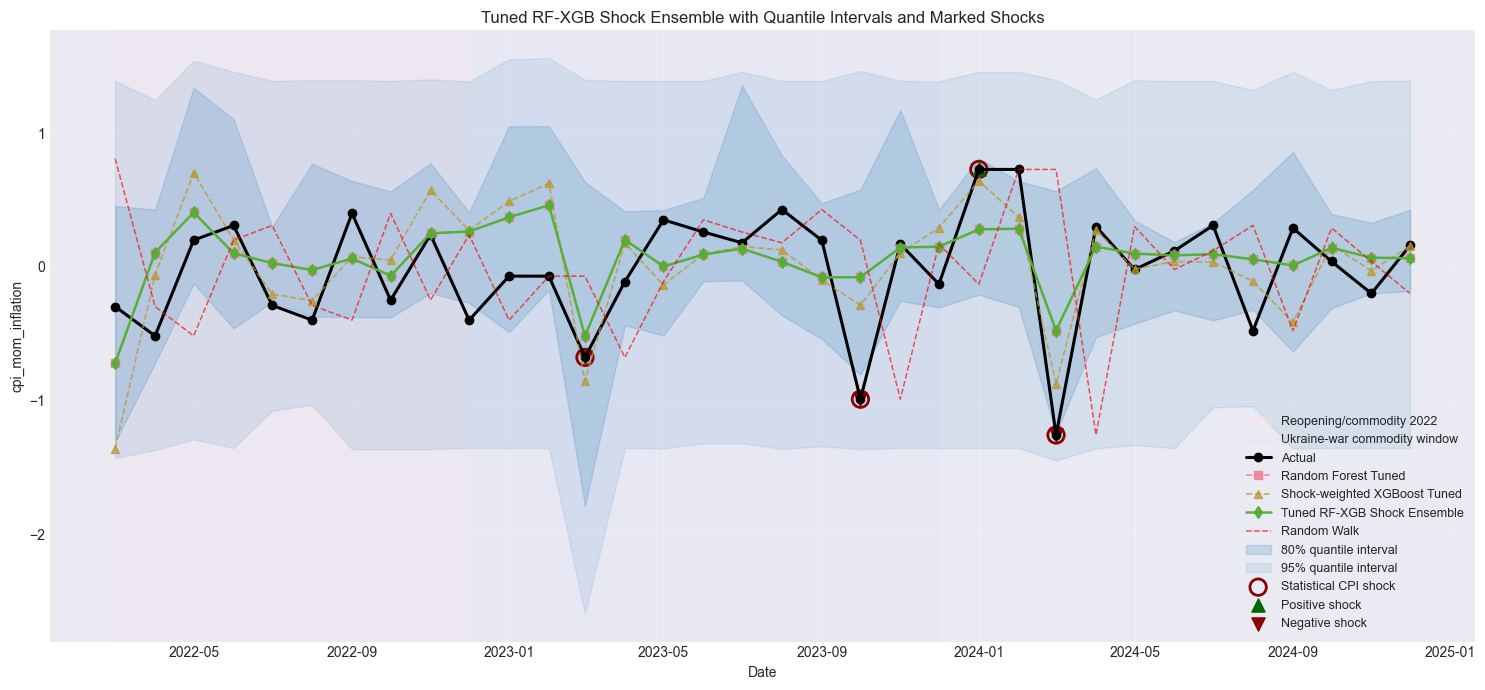

In [17]:
# Forecast plot with shock markers and event windows
fig, ax = plt.subplots(figsize=(15, 7))

for start, end, color, label in [
    ("2020-03-01", "2021-12-01", "lightgray", "COVID period"),
    ("2022-01-01", "2022-12-01", "mistyrose", "Reopening/commodity 2022"),
    ("2022-02-01", "2023-12-01", "lavender", "Ukraine-war commodity window"),
]:
    start_ts, end_ts = pd.Timestamp(start), pd.Timestamp(end)
    if end_ts >= y_test.index.min() and start_ts <= y_test.index.max():
        ax.axvspan(max(start_ts, y_test.index.min()), min(end_ts, y_test.index.max()), alpha=0.25, color=color, label=label)

ax.plot(y_test.index, y_test.values, "o-", label="Actual", color="black", linewidth=2.2)
ax.plot(y_test.index, rf_test_pred, "s--", label="Random Forest Tuned", linewidth=1.2, alpha=0.75)
ax.plot(y_test.index, xgb_test_pred, "^--", label="Shock-weighted XGBoost Tuned", linewidth=1.2, alpha=0.75)
ax.plot(y_test.index, ensemble_test_pred, "d-", label="Tuned RF-XGB Shock Ensemble", linewidth=1.8, alpha=0.95)
ax.plot(y_test.index[rw_mask], rw_pred[rw_mask], "--", label="Random Walk", color="red", linewidth=1.1, alpha=0.65)

ax.fill_between(y_test.index, lower80, upper80, alpha=0.18, color="tab:blue", label="80% quantile interval")
ax.fill_between(y_test.index, lower95, upper95, alpha=0.10, color="tab:blue", label="95% quantile interval")

shock_dates = y_test.index[labels_test["stat_shock"].astype(bool)]
ax.scatter(shock_dates, y_test.loc[shock_dates], s=140, facecolors="none", edgecolors="darkred", linewidths=2.0, label="Statistical CPI shock")

pos_dates = y_test.index[labels_test["positive_stat_shock"].astype(bool)]
neg_dates = y_test.index[labels_test["negative_stat_shock"].astype(bool)]
ax.scatter(pos_dates, y_test.loc[pos_dates], marker="^", s=90, color="darkgreen", label="Positive shock")
ax.scatter(neg_dates, y_test.loc[neg_dates], marker="v", s=90, color="darkred", label="Negative shock")

ax.set_title("Tuned RF-XGB Shock Ensemble with Quantile Intervals and Marked Shocks")
ax.set_xlabel("Date")
ax.set_ylabel(target_var)
ax.legend(loc="best", fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "tuned_rf_xgb_shock_ensemble_forecast.png"), dpi=150)
plt.show()

In [18]:
# Detailed prediction table with shock markers
prediction_df = pd.DataFrame({
    "actual": y_test,
    "rf_pred": rf_test_pred,
    "xgb_shock_pred": xgb_test_pred,
    "ensemble_pred": ensemble_test_pred,
    "random_walk": rw_pred,
    "q10": lower80,
    "q90": upper80,
    "q025": lower95,
    "q975": upper95,
    "inflation_zscore_12": labels_test["inflation_zscore_12"],
    "stat_shock": labels_test["stat_shock"],
    "positive_stat_shock": labels_test["positive_stat_shock"],
    "negative_stat_shock": labels_test["negative_stat_shock"],
})

for col in event_cols:
    prediction_df[col] = add_event_features(prediction_df.index)[col]

prediction_df["ensemble_error"] = prediction_df["actual"] - prediction_df["ensemble_pred"]
prediction_df["ensemble_abs_error"] = prediction_df["ensemble_error"].abs()
prediction_df["inside_80_interval"] = ((prediction_df["actual"] >= prediction_df["q10"]) & (prediction_df["actual"] <= prediction_df["q90"])).astype(int)
prediction_df["inside_95_interval"] = ((prediction_df["actual"] >= prediction_df["q025"]) & (prediction_df["actual"] <= prediction_df["q975"])).astype(int)

marked_shocks = prediction_df[prediction_df["stat_shock"] == 1].copy()

print("Marked shock points in test set")
if len(marked_shocks) > 0:
    print(marked_shocks.round(6).to_string())
else:
    print("No statistical shocks in test set under current threshold.")

prediction_df.to_csv(os.path.join(OUTPUT_DIR, "test_predictions_with_shock_markers.csv"))
marked_shocks.to_csv(os.path.join(OUTPUT_DIR, "marked_test_shock_points.csv"))

Marked shock points in test set
              actual   rf_pred  xgb_shock_pred  ensemble_pred  random_walk       q10       q90      q025      q975  inflation_zscore_12  stat_shock  positive_stat_shock  negative_stat_shock  gfc_2008_2011  covid_period  reopening_commodity_2022  ukraine_war_commodity  tet_window  school_fee_window  year_end_window  ensemble_error  ensemble_abs_error  inside_80_interval  inside_95_interval
date                                                                                                                                                                                                                                                                                                                                                                                                   
2023-03-01 -0.676954 -0.517629       -0.855144      -0.517629    -0.069638 -1.787591  0.634381 -2.592975  1.397227            -1.864876         1.0                  0.0                

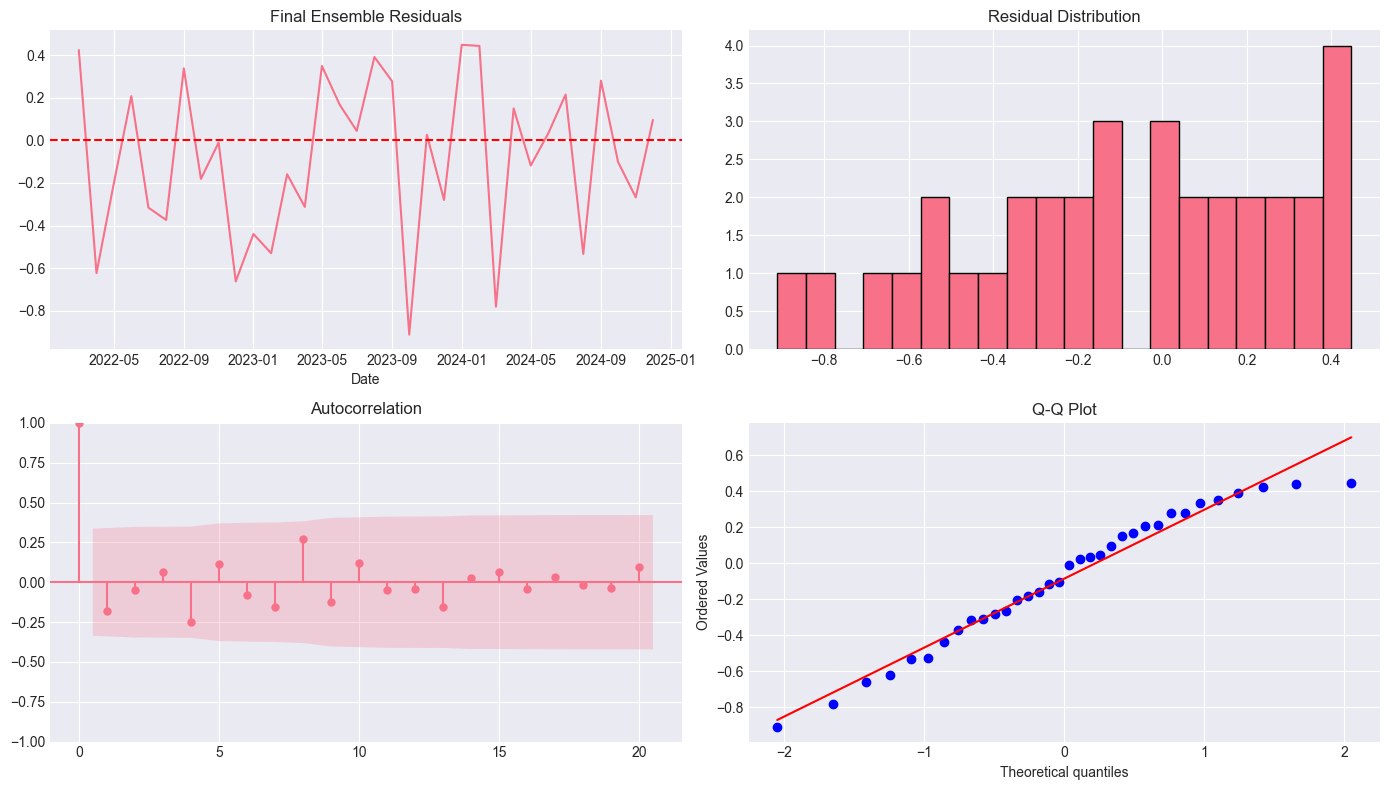

Residual mean: -0.086048
Residual std:  0.370174
Jarque-Bera p-value: 0.431271


In [19]:
# Residual diagnostics for final ensemble
residuals = y_test.values - ensemble_test_pred.values
max_lags = min(20, len(residuals) - 1)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes[0, 0].plot(y_test.index, residuals)
axes[0, 0].axhline(0, color="red", linestyle="--")
axes[0, 0].set_title("Final Ensemble Residuals")
axes[0, 0].set_xlabel("Date")

axes[0, 1].hist(residuals, bins=20, edgecolor="black")
axes[0, 1].set_title("Residual Distribution")

plot_acf(residuals, lags=max_lags, ax=axes[1, 0])
stats.probplot(residuals, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title("Q-Q Plot")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "final_ensemble_residual_diagnostics.png"), dpi=150)
plt.show()

jb_stat, jb_p = jarque_bera(residuals)
print(f"Residual mean: {np.mean(residuals):.6f}")
print(f"Residual std:  {np.std(residuals):.6f}")
print(f"Jarque-Bera p-value: {jb_p:.6f}")

Running SHAP for final XGBoost component...
Top 25 XGBoost SHAP features on test
                       feature  mean_abs_shap
                     month_sin       0.256513
       cpi_mom_inflation_lag24       0.098434
                      dlog_wti       0.079658
          dlog_USDVND_abs_lag1       0.044472
        cpi_mom_inflation_lag2       0.040388
       cpi_mom_inflation_lag12       0.039091
       cpi_mom_inflation_lag23       0.036400
 cpi_mom_inflation_roll_std_12       0.036139
 cpi_mom_inflation_roll_mean_6       0.032461
 cpi_mom_inflation_roll_mean_3       0.030712
       cpi_mom_inflation_lag19       0.029927
cpi_mom_inflation_roll_mean_12       0.028356
      dlog_USDVND_roll_mean_12       0.027740
                  dlog_VNINDEX       0.027470
       dlog_VNINDEX_roll_std_3       0.027452
                dlog_wti_lag12       0.025982
              dlog_broad_money       0.023262
       dlog_USDVND_roll_mean_6       0.023017
         dlog_broad_money_lag3       0.021428

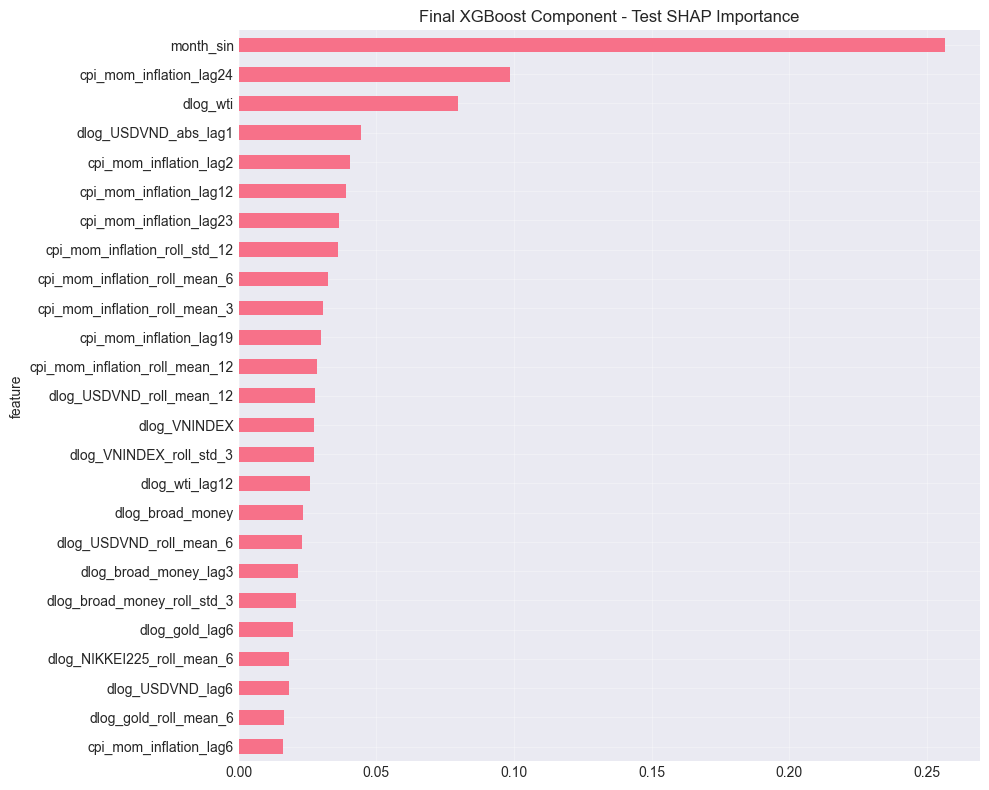

In [20]:
# Final SHAP for XGBoost component
if HAS_SHAP and HAS_XGB:
    print("Running SHAP for final XGBoost component...")
    explainer = shap.TreeExplainer(xgb_final)
    shap_values_test = explainer.shap_values(X_test_sel)

    shap_importance_test = pd.DataFrame({
        "feature": X_test_sel.columns,
        "mean_abs_shap": np.abs(shap_values_test).mean(axis=0)
    }).sort_values("mean_abs_shap", ascending=False)

    print("Top 25 XGBoost SHAP features on test")
    print(shap_importance_test.head(25).to_string(index=False))

    fig, ax = plt.subplots(figsize=(10, 8))
    shap_importance_test.head(25).iloc[::-1].plot(x="feature", y="mean_abs_shap", kind="barh", ax=ax, legend=False)
    ax.set_title("Final XGBoost Component - Test SHAP Importance")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "final_xgb_component_shap_importance.png"), dpi=150)
    plt.show()

    shap_importance_test.to_csv(os.path.join(OUTPUT_DIR, "final_xgb_component_shap_importance.csv"), index=False)
else:
    print("SHAP final analysis skipped.")

In [21]:
print("\n" + "="*80)
print("TUNED RF-XGBOOST SHOCK ENSEMBLE SUMMARY")
print("="*80)
print(f"Target: {target_var}")
print(f"Use current exogenous variables: {USE_CURRENT_EXOG}")
print(f"Supervised observations: {len(X)}")
print(f"Selected features: {len(selected_features)}")
print(f"Train period: {X_train.index.min().date()} to {X_train.index.max().date()}")
print(f"Validation period: {X_val.index.min().date()} to {X_val.index.max().date()}")
print(f"Test period: {X_test.index.min().date()} to {X_test.index.max().date()}")
print(f"Train shocks: {int(labels_train['stat_shock'].sum())}")
print(f"Validation shocks: {int(labels_val['stat_shock'].sum())}")
print(f"Test shocks: {int(labels_test['stat_shock'].sum())}")
print(f"Best RF params: {best_rf_params}")
print(f"Best XGB params: {best_xgb_params}")
print(f"Best shock weight: {best_shock_weight}")
print(f"Best ensemble weights: RF={best_w_rf:.2f}, XGB={best_w_xgb:.2f}")
print("\nFinal test comparison:")
print(results_df.to_string(index=False))
print("\nShock vs non-shock comparison:")
print(shock_results_df.to_string(index=False))
print("\nQuantile interval diagnostics:")
print(interval_df.to_string(index=False))
print("="*80)


TUNED RF-XGBOOST SHOCK ENSEMBLE SUMMARY
Target: cpi_mom_inflation
Use current exogenous variables: True
Supervised observations: 335
Selected features: 40
Train period: 1997-02-01 to 2019-05-01
Validation period: 2019-06-01 to 2022-02-01
Test period: 2022-03-01 to 2024-12-01
Train shocks: 45
Validation shocks: 6
Test shocks: 4
Best RF params: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 200}
Best XGB params: {'colsample_bytree': 0.75, 'learning_rate': 0.03, 'max_depth': 5, 'n_estimators': 400, 'reg_alpha': 0.1, 'reg_lambda': 2.0, 'subsample': 0.75}
Best shock weight: 3.0
Best ensemble weights: RF=1.00, XGB=0.00

Final test comparison:
                       Model     RMSE      MAE       R2  Model_vs_RW  Model_vs_Mean
         Random Forest Tuned 0.380044 0.314579 0.223416     0.544418       0.881240
 Tuned RF-XGB Shock Ensemble 0.380044 0.314579 0.223416     0.544418       0.881240
Shock-weighted XGBoost Tuned 0.400395 0.316074 0.138016     0.573572